# Pipeline de forecasting — preço do petróleo Brent

Notebook obrigatório da prova substitutiva: extração, features, treino temporal, métricas e serialização do modelo campeão.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_or_refresh, series_summary
from src.feature_engineering import build_features, feature_columns, recursive_forecast
from src.model_trainer import save_bundle, temporal_split, train_and_select

raw = load_or_refresh(refresh=False)
display(pd.Series(series_summary(raw), name='serie'))

n_obs                    10049
start               1987-05-20
end                 2026-08-25
last_price               88.24
min_price                  9.1
max_price               143.95
source        EIA366_PBRENT366
serid               1650971490
Name: serie, dtype: object

## Engenharia de atributos

Lags t−1, t−2, t−3, t−5, t−7, t−15, t−30; médias 7/14/30/90; volatilidade 7/30; calendário. Janelas móveis usam apenas t−1 para evitar vazamento.

In [2]:
features = build_features(raw)
cols = feature_columns()
print('atributos:', cols)
print('shape:', features.shape)
features[['date', 'price', *cols[:6]]].tail()

atributos: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_15', 'lag_30', 'ma_7', 'ma_14', 'ma_30', 'ma_90', 'vol_7', 'vol_30', 'weekday', 'month', 'quarter', 'dayofyear']
shape: (9959, 20)


,date,price,lag_1,lag_2,lag_3,lag_5,lag_7,lag_15
9954,2026-08-19,92.37,95.29,92.43,92.02,92.52,92.74,91.95
9955,2026-08-20,94.00,92.37,95.29,92.43,92.03,93.26,91.91
9956,2026-08-21,96.92,94.00,92.37,95.29,92.02,92.52,96.95
9957,2026-08-24,92.71,96.92,94.00,92.37,92.43,92.03,88.90
9958,2026-08-25,88.24,92.71,96.92,94.00,95.29,92.02,86.47


## Treinamento comparativo (Time Series Split)

Últimos 60 dias úteis ficam no teste. Sem shuffle. Candidatos: Naive (lag-1), Random Forest, XGBoost; Prophet/SARIMAX/LightGBM se instalados.

In [3]:
bundle = train_and_select(refresh=False, test_days=60)
path = save_bundle(bundle)
print('campeão:', bundle['model_name'])
print('modelo salvo em', path)
display(pd.DataFrame(bundle['comparison']))

campeão: random_forest
modelo salvo em /workspace/app/model.joblib


,model,mape,rmse,mae,r2
0,naive_lag1,3.191290,3.675085,2.793167,0.855656
1,random_forest,3.324444,3.797445,2.901774,0.845884
2,xgboost,3.379939,3.977124,2.960822,0.830955
3,sarimax,16.413455,15.772149,12.868202,-1.658552


## Métricas no conjunto de teste (1 passo à frente)

In [4]:
display(pd.Series(bundle['metrics'], name='teste_1_passo'))
if bundle.get('horizon_metrics'):
    display(pd.DataFrame(bundle['horizon_metrics']).T.rename_axis('horizonte'))

mape    3.324444
rmse    3.797445
mae     2.901774
r2      0.845884
Name: teste_1_passo, dtype: float64

,mape,rmse,mae,r2,n
horizonte,,,,,
7,2.244675,2.675542,2.151203,0.057159,7.0
15,12.451927,12.916216,10.088622,-1.179520,15.0
30,23.101010,19.709970,17.224104,-2.685480,30.0


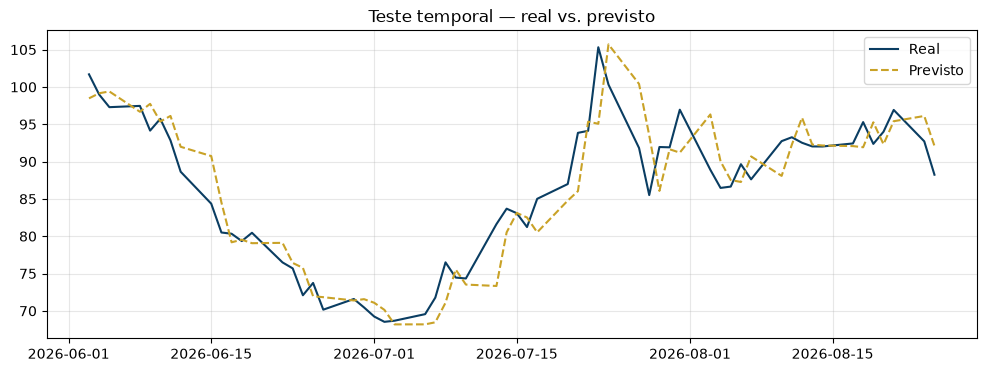

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(bundle['y_dates']), bundle['y_true'], label='Real', color='#0A3D62')
ax.plot(pd.to_datetime(bundle['y_dates']), bundle['y_pred'], label='Previsto', color='#C9A227', linestyle='--')
ax.set_title('Teste temporal — real vs. previsto')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Projeção recursiva a partir do último preço oficial

,date,predicted,lower,upper,horizon
0,2026-08-26,88.594489,81.092640,96.096339,1
1,2026-08-27,89.817032,79.207815,100.426249,2
2,2026-08-28,89.863783,76.870199,102.857367,3
3,2026-08-31,89.875474,74.871775,104.879173,4
4,2026-09-01,90.385964,73.611319,107.160609,5
5,2026-09-02,90.057029,71.681326,108.432732,6
6,2026-09-03,89.369928,69.521900,109.217955,7
7,2026-09-04,89.481811,68.263377,110.700245,8
8,2026-09-07,89.166320,66.660772,111.671868,9
9,2026-09-08,88.793349,65.070418,112.516279,10


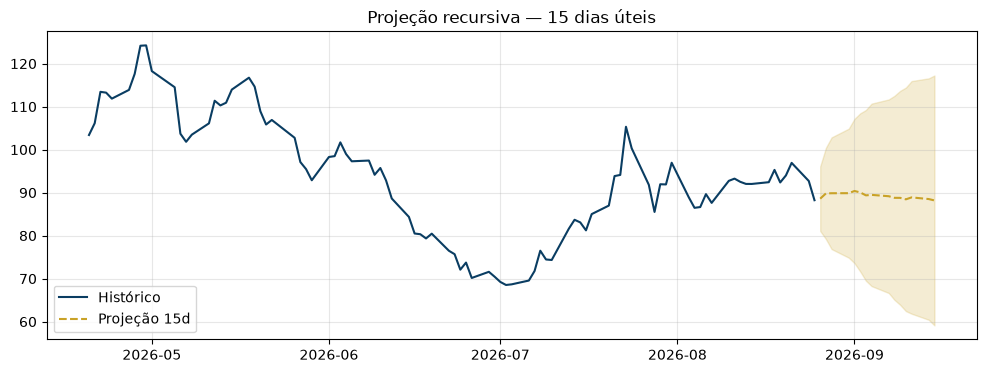

In [6]:
forecast = recursive_forecast(
    bundle['model'],
    raw,
    horizon=15,
    feature_cols=bundle['feature_columns'],
    residual_std=bundle['residual_std'],
)
display(forecast)
fig, ax = plt.subplots(figsize=(12, 4))
hist = raw.tail(90)
ax.plot(hist['date'], hist['price'], label='Histórico', color='#0A3D62')
ax.plot(forecast['date'], forecast['predicted'], label='Projeção 15d', color='#C9A227', linestyle='--')
ax.fill_between(forecast['date'], forecast['lower'], forecast['upper'], color='#C9A227', alpha=0.2)
ax.set_title('Projeção recursiva — 15 dias úteis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Governança

- Métrica principal: MAPE de curto prazo (meta ≤ 5% em 7–15 dias).
- RMSE e MAE em US$ para a mesa de trading.
- Validação em janela expansiva registrada em `bundle['rolling_cv']`.
- Artefato de produção: `app/model.joblib`.

In [7]:
display(pd.DataFrame(bundle.get('rolling_cv', [])))
print('train_end', bundle['train_end'], 'teste', bundle['test_start'], '→', bundle['test_end'])

,mape,rmse,mae,r2,fold,test_start,test_end
0,3.572225,4.331631,3.179494,0.772904,1,2026-07-01,2026-08-25
1,3.354008,4.054502,3.189057,0.915569,2,2026-05-05,2026-06-30
2,4.291353,6.361314,4.776891,0.675184,3,2026-03-05,2026-05-01
3,1.972972,2.034395,1.411638,0.717120,4,2026-01-08,2026-03-04


train_end 2026-06-02 teste 2026-06-03 → 2026-08-25
